## Feature calculation & visualization

In [34]:
import Human_SleepSCoring.Tim.Sleep_Scripts.average_feature_visualizations as F
import mne
import Human_SleepSCoring.Tim.DeepNeuralNetworkSleep.hdf5_files.Artefacts_Detection as A
import pickle
from joblib import Parallel, delayed
from scipy.signal import hilbert
import os
import numpy as np
import pandas as pd
import Human_SleepSCoring.Tim.Sleep_Scripts.Cleaned_feature_vis as C

In [35]:
noise_band = [0,0.5]
delta_band = [0.5,5]
theta_band = [6,10]
sigma_band = [11,17]
beta_band = [22,30]
gamma_band = [35,45]
total_band = [0,30]
alpha_band = [8,13]

### Functions

In [36]:
def Index_1(delta, gamma, EMG):
  index_1 = np.array([])
  for i in range(len(delta)):
    value = (EMG[i]*gamma[i])/(delta[i])
    index_1 = np.append(index_1, [value])
  return index_1
  
def Index_2(delta, theta, sigma):
  index_2 = np.array([])
  for i in range(len(delta)):
    value = (sigma[i]*delta[i])/(theta[i])
    index_2 = np.append(index_2, [value])
  return index_2
  
def Index_3(delta, theta, gamma):
  index_3 = np.array([])
  for i in range(len(delta)):
    value = (theta[i]*gamma[i])/(delta[i])
    index_3 = np.append(index_3, [value])
  return index_3
  
def Index_4(delta, theta):
  index_4 = np.array([])
  for i in range(len(delta)):
    value = delta[i]/theta[i]
    index_4 = np.append(index_4, [value])
  return index_4
  
def index_W(theta, gamma, EMG):
  index_w = np.array([])
  for i in range(len(theta)):
    value = EMG[i]*EMG[i]*((gamma[i])/(theta[i]))
    index_w = np.append(index_w, [value])
  return index_w

def index_R(delta, theta, sigma, EMG, gamma):
  index_r = np.array([])
  for i in range(len(delta)):
    value = ((theta[i]*2)*gamma[i])/(delta[i]*delta[i]*EMG[i]**2)
    index_r = np.append(index_r, [value])
  return index_r

def index_N(delta, sigma, gamma):
  index_n = np.array([])
  for i in range(len(delta)):
    value = (sigma[i]*delta[i])/(gamma[i]**2)
    index_n = np.append(index_n, [value])
  return index_n

In [46]:
def psd_multitaper(lfp_data, fs, frequency_band, window_length):
    """
    Compute power spectral density (PSD) for an LFP signal using the multitaper method.

    Parameters
    ----------
    lfp_data : np.ndarray
        1D array of LFP signal values.
    fs : float
        Sampling frequency of the LFP signal in Hz.
    frequency_band : tuple(float, float)
        Frequency band (fmin, fmax) over which to calculate PSD.
    window_length : int
        Number of samples in each segment/window for PSD computation.

    Returns
    -------
    all_power_sum : list of float
        Sum of PSD values for each window in the specified frequency band.
    
    Notes
    -----
    Splits the signal into non-overlapping windows of length `window_length`
    and computes the multitaper PSD for each window, summing the power within
    the specified frequency band.
    """
    all_power_sum = []

    # Loop over non-overlapping windows of the signal
    for start in range(0, len(lfp_data) - window_length + 1, window_length):
        window = lfp_data[start:min(start + window_length, len(lfp_data))]

        # Compute PSD using MNE multitaper method
        psd, freqs = mne.time_frequency.psd_array_multitaper(
            window, fs, fmin=frequency_band[0], fmax=frequency_band[1], n_jobs=1, verbose='warning'
        )

        # Sum PSD values in the specified frequency band
        freq_indices = (freqs >= frequency_band[0]) & (freqs <= frequency_band[1])
        curr_sum = np.sum(psd[freq_indices])
        all_power_sum.append(curr_sum)

    return all_power_sum


def wei_normalizing(data):
    """
    Perform robust normalization of a 1D array based on 10th and 90th percentiles.

    Parameters
    ----------
    data : array-like
        Input data to normalize.

    Returns
    -------
    normalized_data : np.ndarray
        Normalized array scaled between 0.05 and 1. Values below the 10th percentile
        are mapped to 0.05, and above the 90th percentile to 1.
    
    Notes
    -----
    This normalization reduces the effect of extreme outliers by ignoring
    values outside the 10th–90th percentile range.
    """
    data = np.array(data)

    bottom = data[data <= np.nanpercentile(data, 10)]
    top = data[data >= np.nanpercentile(data, 90)]

    bottom_avg = np.average(bottom) if len(bottom) > 0 else 0
    top_avg = np.average(top) if len(top) > 0 else 1

    denom = top_avg - bottom_avg if top_avg != bottom_avg else 1
    normalized_data = (data - bottom_avg) / denom
    normalized_data = np.clip(normalized_data, 0.05, 1)

    return normalized_data


def fragment_join(subject, night, type):
    """
    Find LFP files and corresponding hypnogram files for a subject and night.

    Parameters
    ----------
    subject : str
        Subject identifier.
    night : int
        Night/session number.
    type : str
        Subfolder/type of recordings (e.g., 'raw', 'preprocessed').

    Returns
    -------
    files : list of str
        Full paths to LFP files for the specified night.
    scores : list of str
        Full paths to corresponding hypnogram files.
    
    Notes
    -----
    Matches files based on the naming convention containing 'night{night}'
    and assumes hypnogram files have a '_hypnogram.npy' suffix.
    """
    base = f"D:/EEG_Data_stage/{subject}/iEEG/{type}"
    score_base = f"D:/EEG_Data_stage/{subject}/iEEG/U_sleep_API_10s"
    files = []
    scores = []

    for file in os.listdir(base):
        if f"night{night}" in file and ".vhdr" in file:
            files.append(os.path.join(base, file))
            scores.append(os.path.join(score_base, file.replace(".vhdr", "_hypnogram.npy")))

    return files, scores


def average_means_dicts(*means_dicts):
    """
    Average multiple nested mean dictionaries across subjects or nights.

    Parameters
    ----------
    *means_dicts : dict
        Dictionaries containing 'index_means' per state and index.

    Returns
    -------
    averaged : dict
        Nested dictionary with the average of each index per state, ignoring NaNs.
    
    Notes
    -----
    Useful for combining results from multiple subjects or nights.
    """
    all_states = means_dicts[0]['index_means'].keys()
    averaged = {}

    for state in all_states:
        averaged[state] = {}
        for key in means_dicts[0]['index_means'][state].keys():
            values = [
                m['index_means'][state][key]
                for m in means_dicts
                if not np.isnan(m['index_means'][state][key])
            ]
            averaged[state][key] = np.mean(values) if values else np.nan

    return averaged


def average_per_index_per_state(loaded_dicts):
    """
    Compute mean values for multiple sleep indices (e.g., W, N, R, 1–4) per sleep state.

    Parameters
    ----------
    loaded_dicts : list of dict
        Feature dictionaries for each subject/night containing 'index_vals' and 'dfa_violin'.

    Returns
    -------
    results : dict
        Nested dictionary with structure results[subject][night][index][state] = mean value.
    
    Notes
    -----
    Ensures all arrays are trimmed to the same length to match hypnogram states.
    """
    results = {}

    state_names = ["w", "n1", "n2", "n3", "r"]
    state_values = [0, 1, 2, 3, 4]
    index_keys = ["W", "N", "R", "1", "2", "3", "4"]

    for diction in loaded_dicts:
        subject = diction["subject"]
        night = diction["night"]

        if subject not in results:
            results[subject] = {}

        states = diction["states"]
        night_result = {}

        for idx in index_keys:
            arr = diction["index_vals"][idx]
            min_len = min(len(arr), len(states))
            arr = arr[:min_len]
            trimmed_states = states[:min_len]

            masks = {sn: (trimmed_states == sv) for sn, sv in zip(state_names, state_values)}
            state_avgs = {sn: float(np.mean(arr[masks[sn]])) if len(arr[masks[sn]]) > 0 else np.nan
                          for sn in state_names}

            night_result[idx] = state_avgs

        results[subject][night] = night_result

    return results


def average_per_signal_per_state(loaded_dicts, signal_keys=["noise", "theta", "delta"]):
    """
    Compute per-state averages for specific signals (e.g., spectral bands).

    Parameters
    ----------
    loaded_dicts : list of dict
        Feature dictionaries containing signals and 'dfa_violin' hypnogram.
    signal_keys : list of str
        Keys of signals to average.

    Returns
    -------
    results : dict
        Nested dictionary: results[subject][night][signal_key][state] = mean value.
    
    Notes
    -----
    Aligns signal length with hypnogram length before computing per-state means.
    """
    results = {}

    state_names = ["w", "n1", "n2", "n3", "r"]
    state_values = [0, 1, 2, 3, 4]

    for diction in loaded_dicts:
        subject = diction["subject"]
        night = diction["night"]

        if subject not in results:
            results[subject] = {}

        states = diction["states"]
        night_result = {}

        for key in signal_keys:
            arr = diction[key]
            min_len = min(len(arr), len(states))
            arr = arr[:min_len]
            trimmed_states = states[:min_len]

            masks = {sn: (trimmed_states == sv) for sn, sv in zip(state_names, state_values)}
            state_avgs = {sn: float(np.mean(arr[masks[sn]])) if len(arr[masks[sn]]) > 0 else np.nan
                          for sn in state_names}

            night_result[key] = state_avgs

        results[subject][night] = night_result

    return results

In [38]:
def prepare_aperiodic_avg_data(dicts):
    """
    Prepare per-subject aperiodic averages for plotting.
    Returns a dictionary containing:
        - df_plot: per-subject DataFrame
        - group_means: group-level averages per state
        - labels: list of state labels
        - data_for_violin: per-state data arrays for plotting
        - all_states: list of indices for all states
    """
    data_rows = []
    for i, d in enumerate(dicts):
        if 'aperiodic_avg' not in d:
            continue
        subj_name = f"Subj_{i+1}"
        for state, value in d['aperiodic_avg'].items():
            data_rows.append({'Subject': subj_name, 'State': state, 'Aperiodic': value})

    df = pd.DataFrame(data_rows)
    grouped = df.groupby('State')['Aperiodic'].mean().reset_index()

    return {
        'df_plot': df,
        'group_means': grouped,
        'labels': grouped['State'].tolist(),
        'data_for_violin': [df.loc[df['State'] == s, 'Aperiodic'].dropna().values for s in grouped['State']],
        'all_states': list(range(len(grouped['State'])))
    }

def prepare_dfa_avg_data(dicts):
    """
    Prepare per-subject DFA averages for plotting.
    Returns a dictionary structured for plotting functions similar to aperiodic_avg.
    """
    data_rows = []
    for i, d in enumerate(dicts):
        if 'dfa_avg' not in d:
            continue
        subj_name = f"Subj_{i+1}"
        for state, value in d['dfa_avg'].items():
            data_rows.append({'Subject': subj_name, 'State': state, 'Dfa': value})

    df = pd.DataFrame(data_rows)
    grouped = df.groupby('State')['Dfa'].mean().reset_index()

    return {
        'df_plot': df,
        'group_means': grouped,
        'labels': grouped['State'].tolist(),
        'data_for_violin': [df.loc[df['State'] == s, 'Dfa'].dropna().values for s in grouped['State']],
        'all_states': list(range(len(grouped['State'])))
    }

def safe_log_normalize(arr):
    """
    Apply log transform and normalization safely.
    - Replace zeros/negatives with small positive value.
    - Take log and normalize using wei_normalizing().
    """
    arr = np.asarray(arr, dtype=float)
    # Replace non-positive values
    if np.any(arr > 0):
        arr = np.where(arr <= 0, np.nanmin(arr[arr > 0]) * 0.1, arr)
    else:
        arr = np.where(arr <= 0, 1e-6, arr)
    arr = np.log(arr)
    return wei_normalizing(arr)

def prepare_mse_avg_data(dicts):
    """
    Prepare per-subject MSE averages for plotting.
    Returns a dictionary with the same structure as other prepare_*_avg_data functions.
    """
    data_rows = []
    for i, d in enumerate(dicts):
        if 'mse_avg' not in d or not isinstance(d['mse_avg'], dict):
            continue
        subj_name = f"Subj_{i+1}"
        for state, value in d['mse_avg'].items():
            if state is None:
                continue
            data_rows.append({'subject': subj_name, 'state': state, 'mse': value})

    if not data_rows:
        return {'df_plot': pd.DataFrame(columns=['subject', 'state', 'mse']),
                'group_means': pd.DataFrame(columns=['state', 'mse']),
                'labels': [],
                'data_for_violin': [],
                'all_states': []}

    df = pd.DataFrame(data_rows)
    grouped = df.groupby('state')['mse'].mean().reset_index()

    return {
        'df_plot': df,
        'group_means': grouped,
        'labels': grouped['state'].tolist(),
        'data_for_violin': [df.loc[df['state'] == s, 'mse'].dropna().values for s in grouped['state']],
        'all_states': list(range(len(grouped['state'])))
    }

def trim_features_to_states(features, states_array):
    """
    Trim feature arrays inside the features dict so their lengths match states_array length.
    Only trims from the end.
    """
    target_len = len(states_array)

    # Trim index_vals
    for key in features["index_vals"]:
        features["index_vals"][key] = features["index_vals"][key][:target_len]

    # Trim top-level feature arrays
    keys_to_trim = ["noise", "theta", "delta"]
    for key in keys_to_trim:
        features[key] = features[key][:target_len]

    return features

In [39]:
def avg_plots(raw, hpc_channel, pfc_channel, states, output_dir, epoch_length, fs, window_length, subject, night):
    """
    Compute EEG-derived features and indices per behavioral state for a given subject and night.
    
    This function performs the following steps:
    1. Bandpass filters EMG data.
    2. Extracts HPC and PFC channel data.
    3. Processes EMG by epoching, summing, and applying a Hilbert transform.
    4. Removes artifacts from HPC and PFC signals.
    5. Computes or loads cached PSDs for multiple frequency bands.
    6. Normalizes and smooths PSDs and EMG.
    7. Computes spectral indices (wake, NREM, REM) and additional custom indices.
    8. Computes per-state means of indices.
    9. Computes aperiodic exponents, DFA, and MSE features for PFC signals.
    10. Prepares per-window and average values for plotting.
    11. Combines all features into a single dictionary and saves them to disk.
    
    Parameters
    ----------
    raw : mne.io.Raw
        Raw EEG object containing continuous recordings.
    hpc_channel : str
        Name of the hippocampus channel.
    pfc_channel : str
        Name of the prefrontal cortex channel.
    states : np.ndarray
        Array of behavioral state labels corresponding to epochs.
    output_dir : str
        Directory where cached PSDs and feature files will be saved.
    epoch_length : int
        Length of each epoch in seconds.
    fs : int
        Sampling frequency of the recording (Hz).
    window_length : int
        Length of window used in PSD computation (samples).
    subject : str
        Subject identifier.
    night : str or int
        Night/session identifier.

    Returns
    -------
    features : dict
        Dictionary containing all computed features, indices, and per-state averages:
        - 'index_means': average values of spectral indices per state
        - 'aperiodic_violin', 'dfa_violin', 'mse_violin': raw data structures for plotting
        - 'aperiodic_avg', 'dfa_avg', 'mse_avg': mean per-state values
        - 'index_vals': smoothed spectral indices per epoch
        - 'aperiodic_fit', 'dfa', 'mse': smoothed continuous traces
        - 'noise', 'theta', 'delta': smoothed PSD traces for these bands
    """
    
    # --- Bandpass filter EMG to 10-70 Hz ---
    raw.filter(l_freq=10, h_freq=70, picks='EMG1-EMG2')
    
    # --- Extract HPC and PFC signals as 1D arrays ---
    hpc_data = np.ravel(raw.get_data(picks=hpc_channel)[0])
    pfc_data = np.ravel(raw.get_data(picks=pfc_channel)[0])
    
    # --- Preprocess EMG: truncate, reshape to epochs, sum, Hilbert transform ---
    EMG = raw.get_data(picks='EMG1-EMG2')[0]
    EMG = EMG[:len(EMG)//(epoch_length * fs) * (epoch_length * fs)]
    EMG = EMG.reshape(-1, (epoch_length * fs))
    EMG = EMG.sum(axis=1)
    EMG = abs(hilbert(EMG))
    
    # --- Artifact removal parameters ---
    amp_thresh = [6, 4]        # amplitude thresholds for artifact removal
    time_win_thresh = [0.2, 0.1]  # time window thresholds (seconds)
    
    # --- Remove artifacts from HPC and PFC ---
    raw_hpc = A.removeArtefacts(hpc_data, 250, amp_thresh, time_win_thresh)[0]
    raw_pfc = A.removeArtefacts(pfc_data, 250, amp_thresh, time_win_thresh)[0]
    
    # --- Set up cache directory for PSD computation ---
    cache_dir = os.path.join(output_dir, "cached_psd_rodent")
    os.makedirs(cache_dir, exist_ok=True)
    cache_file = os.path.join(cache_dir, f"subject_{subject}_night_{night}_psd.pkl")
    
    # --- Try loading cached PSDs to save computation time ---
    if os.path.exists(cache_file):
        print(f"✅ Loading cached PSDs for subject {subject}, night {night}...")
        with open(cache_file, "rb") as f:
            noise, delta, theta, sigma, beta, gamma, alpha = pickle.load(f)
    else:
        print(f"⚙️ Computing PSDs for subject {subject}, night {night}...")
        
        # List of signals to compute PSDs for each band
        raws = [raw_pfc, raw_pfc, raw_hpc, raw_pfc, raw_pfc, raw_pfc, raw_hpc]
        fr_bands = [noise_band, delta_band, theta_band, sigma_band, beta_band, gamma_band, alpha_band]
        
        # Compute PSDs in parallel
        noise, delta, theta, sigma, beta, gamma, alpha = Parallel(n_jobs=7)(
            delayed(psd_multitaper)(raw_sig, fs, band, window_length)
            for raw_sig, band in zip(raws, fr_bands)
        )
        
        # Save PSDs to cache
        with open(cache_file, "wb") as f:
            pickle.dump((noise, delta, theta, sigma, beta, gamma, alpha), f)
        print(f"💾 PSDs saved to cache: {cache_file}")
    
    # --- Normalize PSDs and EMG ---
    noise_norm = wei_normalizing(noise)
    delta_norm = wei_normalizing(delta)
    theta_norm = wei_normalizing(theta)
    sigma_norm = wei_normalizing(sigma)
    beta_norm = wei_normalizing(beta)
    gamma_norm = wei_normalizing(gamma)
    alpha_norm = wei_normalizing(alpha)
    EMG_norm = wei_normalizing(EMG)
    
    # --- Helper: triple smoothing ---
    def smooth(x, n=5):
        """Smooth signal by triple convolution with a uniform window."""
        return np.convolve(np.convolve(np.convolve(x, np.ones(n)/n, mode='same'),
                                       np.ones(n)/n, mode='same'),
                           np.ones(n)/n, mode='same')
    
    # --- Smooth selected PSDs for plotting ---
    noise_smoothed = smooth(noise_norm)
    delta_smoothed = smooth(delta_norm)
    theta_smoothed = smooth(theta_norm)
    
    # --- Compute state indices ---
    index_n = index_N(delta_norm, sigma_norm, gamma_norm)
    index_r = index_R(delta_norm, theta_norm, sigma_norm, EMG_norm, gamma_norm)
    index_w = index_W(theta_norm, gamma_norm, EMG_norm)
    
    # --- Align lengths to the minimum across indices ---
    min_len = min(len(states), len(index_w), len(index_n), len(index_r))
    mapped_scores = np.ravel(states)[:min_len]
    
    # Trim additional indices to match length
    min_len = min(
        len(index_w), len(index_n), len(index_r),
        len(F.Index_1(delta_norm, gamma_norm, EMG_norm)),
        len(F.Index_2(delta_norm, theta_norm, sigma_norm)),
        len(F.Index_3(delta_norm, theta_norm, gamma_norm)),
        len(F.Index_4(delta_norm, theta_norm))
    )
    index_w = index_w[:min_len]
    index_n = index_n[:min_len]
    index_r = index_r[:min_len]
    index_1 = F.Index_1(delta_norm, gamma_norm, EMG_norm)[:min_len]
    index_2 = F.Index_2(delta_norm, theta_norm, sigma_norm)[:min_len]
    index_3 = F.Index_3(delta_norm, theta_norm, gamma_norm)[:min_len]
    index_4 = F.Index_4(delta_norm, theta_norm)[:min_len]
    
    # --- Apply safe log normalization to all indices ---
    index_w = safe_log_normalize(index_w)
    index_n = safe_log_normalize(index_n)
    index_r = safe_log_normalize(index_r)
    index_1 = safe_log_normalize(index_1)
    index_2 = safe_log_normalize(index_2)
    index_3 = safe_log_normalize(index_3)
    index_4 = safe_log_normalize(index_4)
    
    # --- Compute per-state means of main indices ---
    index_means = F.extract_index_values_per_state(index_n, index_r, index_w, mapped_scores)

    # --- Combine all features into a dictionary ---
    features = {
        'subject': subject,
        'night': night,
        'index_means': index_means,
        'index_vals': {"W": smooth(index_w), "N": smooth(index_n), "R": smooth(index_r),
                       "1": smooth(index_1), "2": smooth(index_2), "3": smooth(index_3), "4": smooth(index_4)},
        'noise': noise_smoothed,
        'theta': theta_smoothed,
        'delta': delta_smoothed,
        'states': mapped_scores
    }
    
    # --- Trim feature arrays to match actual states ---
    features = trim_features_to_states(features, mapped_scores)
    
    # --- Save features to file ---
    feature_file = os.path.join(output_dir, f"features_{subject}_night{night}.npy")
    np.save(feature_file, features)
    print(f"Saved features for {subject}_night{night} to {feature_file}")
    
    return features

### Define contacts to be used

In [40]:
# # Extra-cranial
# electrodes = {
#     "2": ["Oz-Cz", "C3-Cz"],
#     "7": ["Oz-Cz", "C3-Cz"],
#     "15": ["Oz-Cz", "C3-Cz"], 
#     "28": ["Oz-Cz", "C3-Cz"], 
#     "31": ["Oz-Cz", "C3-Cz"],
#     "63": ["Oz-Cz", "C3-Cz"],
#     "67": ["Oz-Cz", "C3-Cz"], 
#     "69": ["Oz-Cz", "C3-Cz"], 
#     "84": ["Oz-Cz", "C3-Cz"], 
#     "85": ["Oz-Cz", "C3-Cz"],
#     "86": ["Oz-Cz", "C3-Cz"],
#     "87": ["C4-Cz", "C3-Cz"],
#     "132": ["C4-Cz", "C3-Cz"], 
#     "134": ["F3", "C4"], 
#     "135": ["F3", "C4"]
# }

In [41]:
# Intra-cranial
# HPC should be index 0 and cortex should be index 1
electrodes = {"2":["TL05", "TLR06"],
              "7":["TL03", "TLR06"],
              "15":["TL05", "TLR01"], 
              "28":["TL07", "TLR06"], 
              "31":["TL05", "TLR12"], 
              "87":["TL05", "TLR01"]}

In [42]:
# Sampling frequency
fs = 250
# Scoring epoch length
epoch_length = 10 
window_length = epoch_length * fs
# Location of EEG data
base_dir = "D:/EEG_Data_stage"
# Name of the EEG folder in the subject folder
file_type = "converted_intra_upscale_strips"
output_dir = os.path.join(base_dir, "plots_rodent_averaged")
cache_dir = os.path.join(base_dir, "cache_rodent")
os.makedirs(output_dir, exist_ok=True)
# Location of the feature files
features_dir = os.path.join(base_dir, "features_intra_rodent")
os.makedirs(features_dir, exist_ok=True)

In [43]:
for file in os.listdir(base_dir):
    if file in electrodes.keys():
        print(f"-----------------------------------Adding subject: {file}-----------------------------------")
        channels = electrodes[file]

        # Handle "28" special case
        nights = [1, 2]

        # Sometimes nights might be missing, fix that here
        if file in ["28", "87"]:
            if file == "28":
                nights = [2]
            else:
                nights = [1]

        for night in nights:
            subject_night = f"{file}_night{night}"
            feature_file = os.path.join(features_dir, f"features_{subject_night}.npy")

            # Skip if the file already exists
            if os.path.exists(feature_file):
                print(f"Skipping {subject_night}, feature file already exists.")
                continue

            print(f"Converting night: {night}")
            subject = file
            night_str = f"{night}"

            hpc_channel = channels[0]
            pfc_channel = channels[1]

            files, scores_files = fragment_join(subject, night_str, file_type)
            raw_list = [mne.io.read_raw_brainvision(f, preload=True) for f in files]
            raw = mne.concatenate_raws(raw_list)
            score_list = [np.load(f) for f in scores_files]
            states = np.concatenate(score_list)

            # Compute your feature
            features = avg_plots(raw, hpc_channel, pfc_channel, states, cache_dir, epoch_length, fs, window_length, file, night)

            # Save it
            np.save(feature_file, features)
            print(f"Saved features for {subject_night} to {feature_file}")

-----------------------------------Adding subject: 2-----------------------------------
Skipping 2_night1, feature file already exists.
Skipping 2_night2, feature file already exists.
-----------------------------------Adding subject: 7-----------------------------------
Skipping 7_night1, feature file already exists.
Skipping 7_night2, feature file already exists.
-----------------------------------Adding subject: 28-----------------------------------
Skipping 28_night2, feature file already exists.
-----------------------------------Adding subject: 15-----------------------------------
Skipping 15_night1, feature file already exists.
Skipping 15_night2, feature file already exists.
-----------------------------------Adding subject: 31-----------------------------------
Skipping 31_night1, feature file already exists.
Skipping 31_night2, feature file already exists.
-----------------------------------Adding subject: 87-----------------------------------
Skipping 87_night1, feature fil

In [47]:
# --- Load feature files ---
features_dir = os.path.join(base_dir, "features_intra_rodent")
all_feature_files = [
    f for f in os.listdir(features_dir)
    if f.startswith("features_") and f.endswith(".npy")
]

loaded_dicts = []
for file_name in all_feature_files:
    file_path = os.path.join(features_dir, file_name)
    data = np.load(file_path, allow_pickle=True).item()
    loaded_dicts.append(data)

print(f"✅ Loaded {len(loaded_dicts)} feature files from {features_dir}")

# --- Combine and average everything ---
if loaded_dicts:
    averaged_index_means = average_means_dicts(*loaded_dicts)
    averaged_indices = average_per_index_per_state(loaded_dicts)
    averaged_power = average_per_signal_per_state(loaded_dicts)

    averaged_features = {
        'index_means': averaged_index_means,
        'index_avg': averaged_indices,
        'power_avg': averaged_power
    }

    print("✅ Averaged features prepared for plotting.")
else:
    averaged_features = {}
    print("⚠️ No feature files found to average.")


✅ Loaded 10 feature files from D:/EEG_Data_stage\features_intra_rodent
✅ Averaged features prepared for plotting.


In [21]:
all_states = np.array([])
# For checking data points per state
for dictionary in loaded_dicts:
    states = dictionary["dfa_violin"]["df_plot"].iloc[:,0].to_numpy()
    all_states = np.append(all_states, states)

unique, counts = np.unique(all_states, return_counts=True)
print(dict(zip(unique, counts)))


{np.float64(0.0): np.int64(15077), np.float64(1.0): np.int64(1080), np.float64(2.0): np.int64(13379), np.float64(3.0): np.int64(2632), np.float64(4.0): np.int64(4756)}


### Visualize the features averaged across subjects

C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\average_feature_visualizations.py:556: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


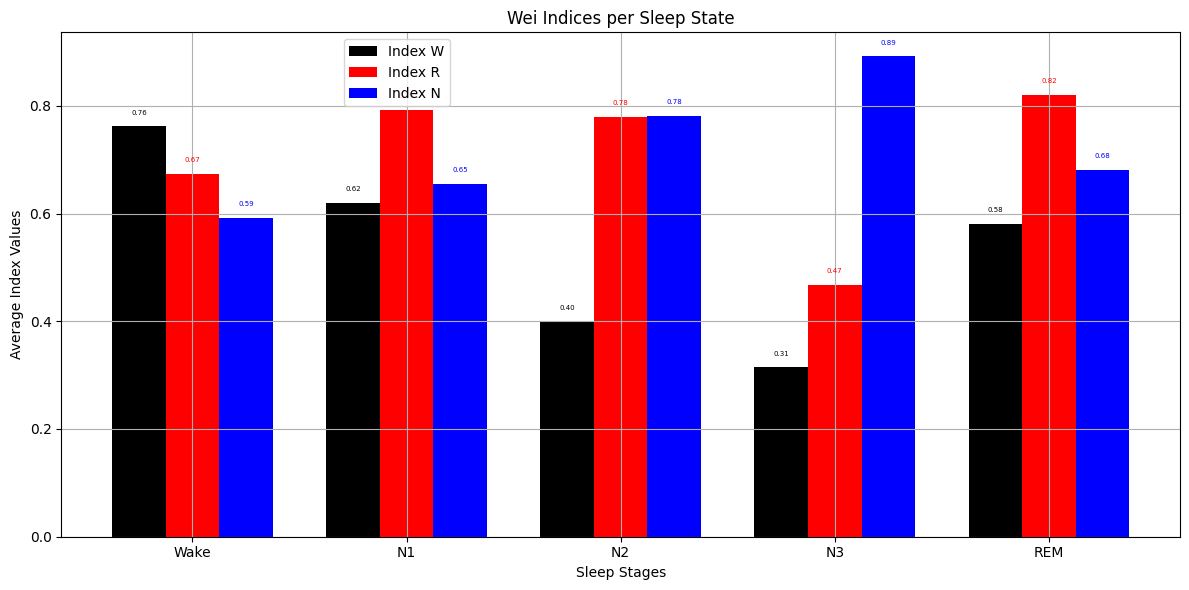

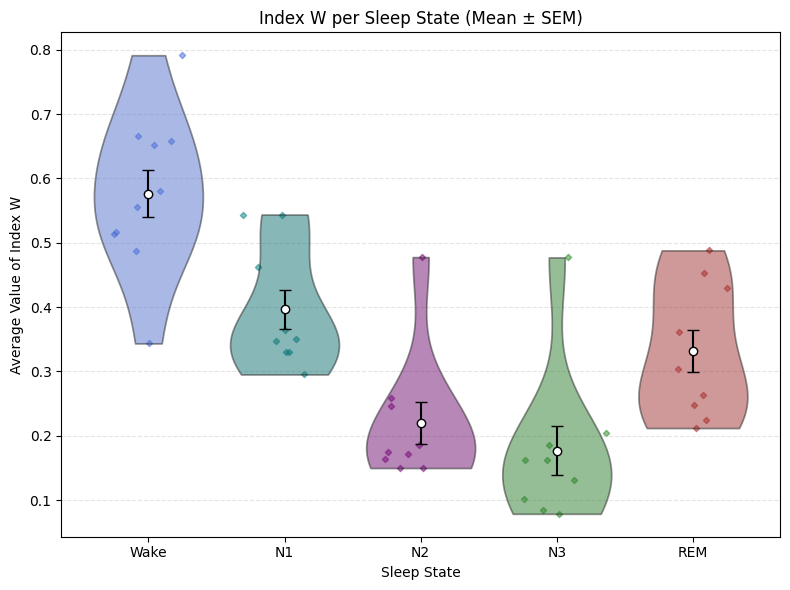

Saved plot: D:/EEG_Data_stage\plots_rodent_averaged\index_W_violin_avg_sem.svg
Saved data: D:/EEG_Data_stage\plots_rodent_averaged\index_W_data.npz


C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\average_feature_visualizations.py:556: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


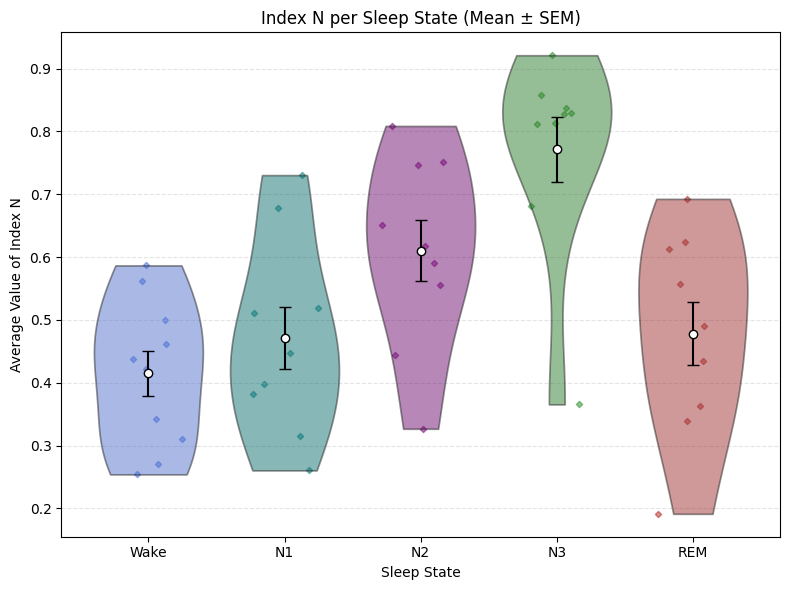

Saved plot: D:/EEG_Data_stage\plots_rodent_averaged\index_N_violin_avg_sem.svg
Saved data: D:/EEG_Data_stage\plots_rodent_averaged\index_N_data.npz


C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\average_feature_visualizations.py:556: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


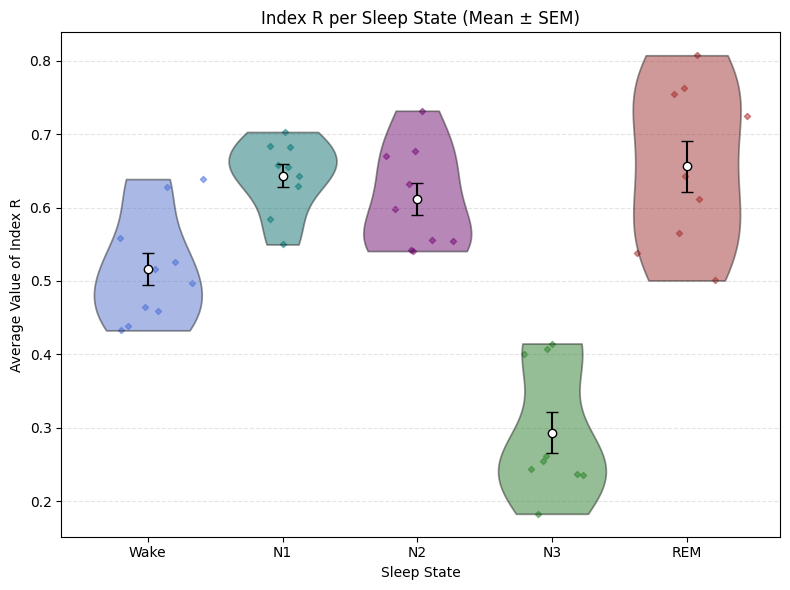

Saved plot: D:/EEG_Data_stage\plots_rodent_averaged\index_R_violin_avg_sem.svg
Saved data: D:/EEG_Data_stage\plots_rodent_averaged\index_R_data.npz


C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\average_feature_visualizations.py:556: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


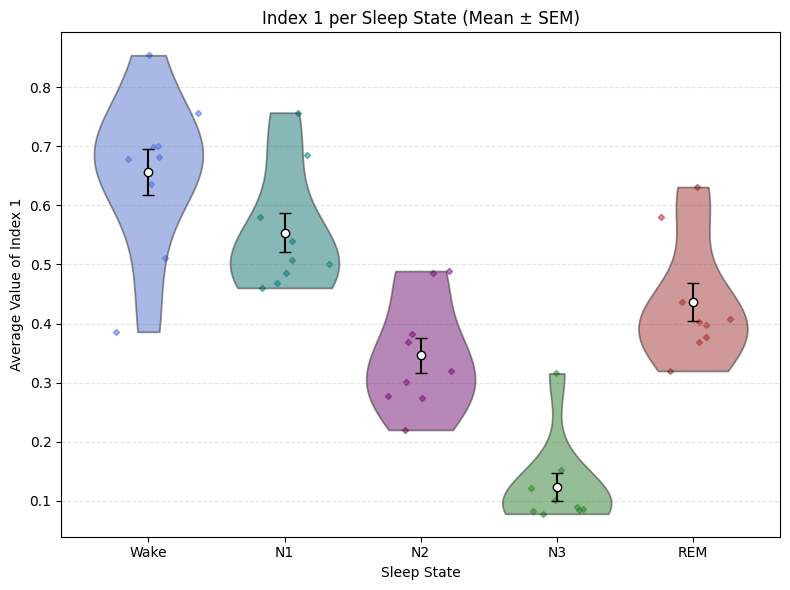

Saved plot: D:/EEG_Data_stage\plots_rodent_averaged\index_1_violin_avg_sem.svg
Saved data: D:/EEG_Data_stage\plots_rodent_averaged\index_1_data.npz


C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\average_feature_visualizations.py:556: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


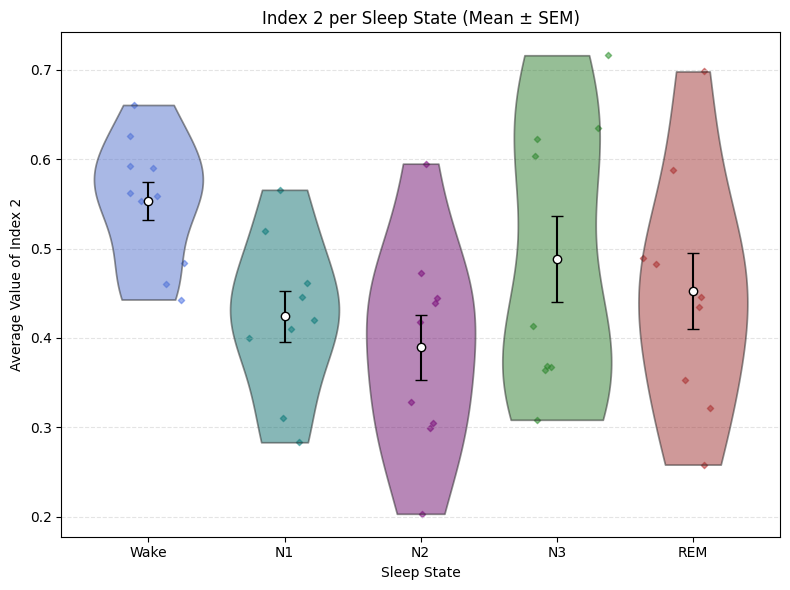

Saved plot: D:/EEG_Data_stage\plots_rodent_averaged\index_2_violin_avg_sem.svg
Saved data: D:/EEG_Data_stage\plots_rodent_averaged\index_2_data.npz


C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\average_feature_visualizations.py:556: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


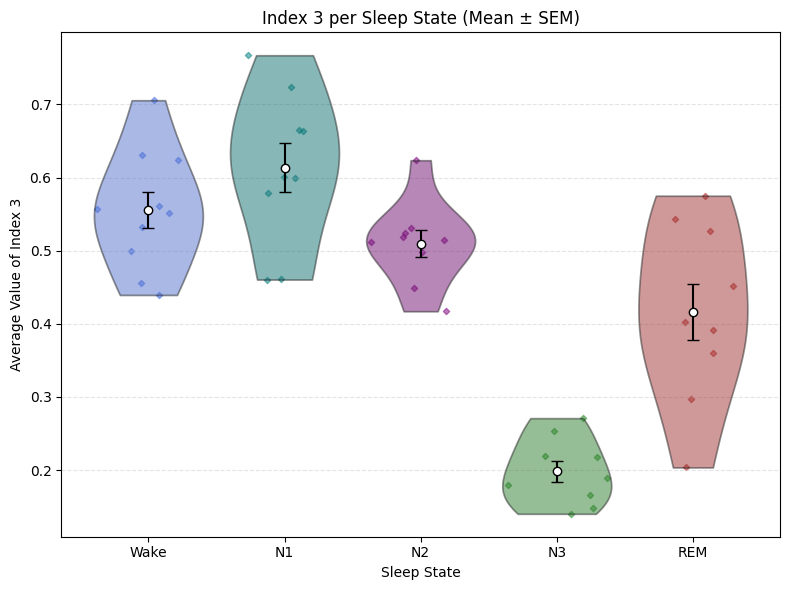

Saved plot: D:/EEG_Data_stage\plots_rodent_averaged\index_3_violin_avg_sem.svg
Saved data: D:/EEG_Data_stage\plots_rodent_averaged\index_3_data.npz


C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\average_feature_visualizations.py:556: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


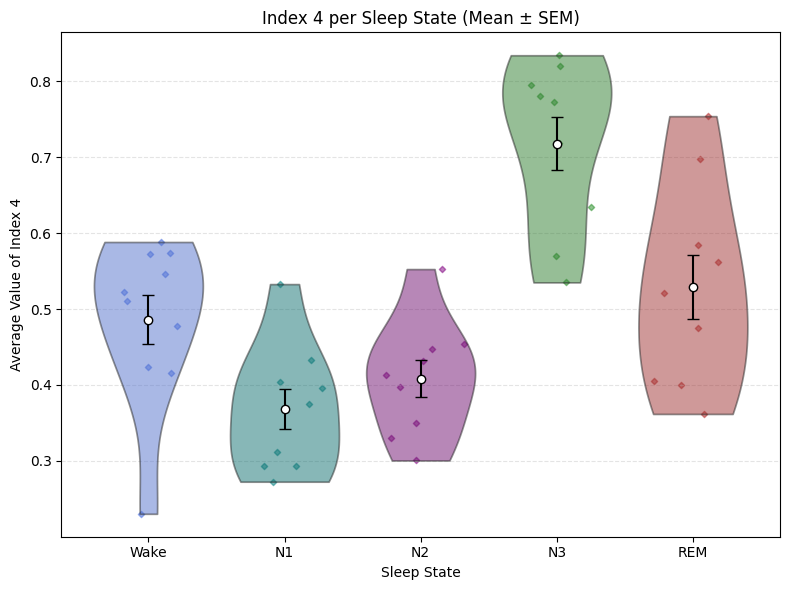

Saved plot: D:/EEG_Data_stage\plots_rodent_averaged\index_4_violin_avg_sem.svg
Saved data: D:/EEG_Data_stage\plots_rodent_averaged\index_4_data.npz


C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\average_feature_visualizations.py:654: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


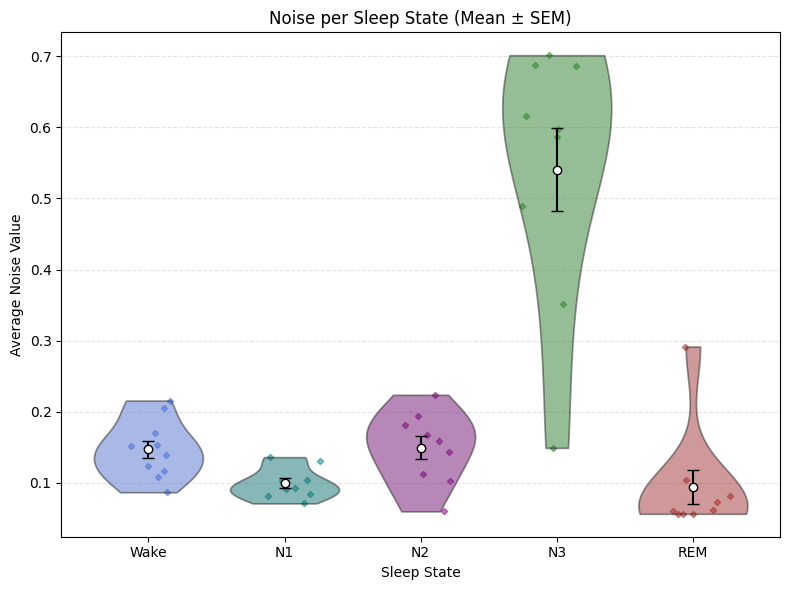

Saved plot: D:/EEG_Data_stage\plots_rodent_averaged\noise_violin_avg_sem.svg
Saved data: D:/EEG_Data_stage\plots_rodent_averaged\noise_data.npz


C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\average_feature_visualizations.py:654: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


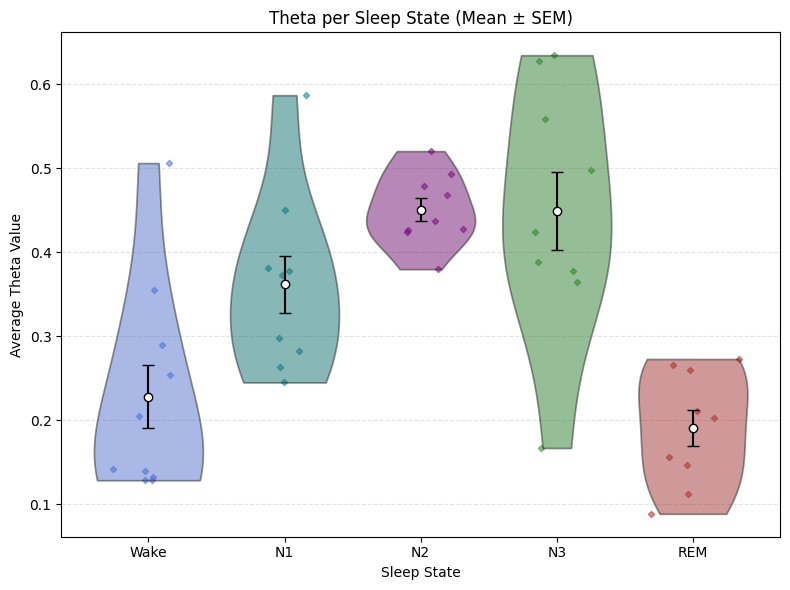

Saved plot: D:/EEG_Data_stage\plots_rodent_averaged\theta_violin_avg_sem.svg
Saved data: D:/EEG_Data_stage\plots_rodent_averaged\theta_data.npz


C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\average_feature_visualizations.py:654: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


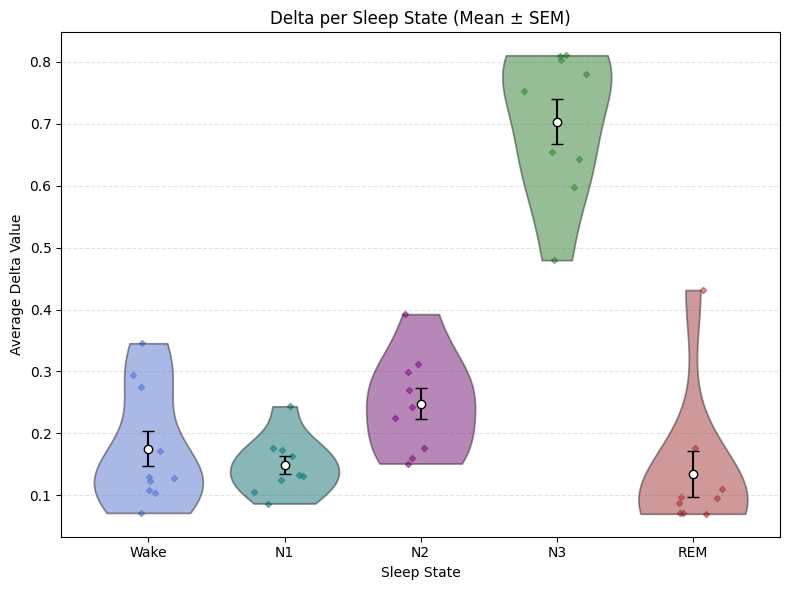

Saved plot: D:/EEG_Data_stage\plots_rodent_averaged\delta_violin_avg_sem.svg
Saved data: D:/EEG_Data_stage\plots_rodent_averaged\delta_data.npz


In [48]:
# Plots averaged by subject
F.plot_index_barplot(averaged_features['index_means'], output_dir)

F.plot_index_avg_violin_all(averaged_features['index_avg'], output_dir)

F.plot_signal_violin_all(averaged_features['power_avg'], output_dir)

### Save subject feature results

In [13]:
for dictionary in loaded_dicts:
    aperiodic_states = dictionary["aperiodic_violin"]["df_plot"].iloc[:,0].to_numpy()
    states = dictionary["dfa_violin"]["df_plot"].iloc[:,0].to_numpy()
    hypno_epochs = np.arange(len(states))
    epochs = np.arange(len(dictionary['index_vals']["W"]))
    out_dir = os.path.join(output_dir, str(dictionary["subject"]), str(dictionary["night"]))
    os.makedirs(out_dir, exist_ok=True)
    F.indices_vs_hypnogram(epochs, hypno_epochs, dictionary['index_vals']["W"], dictionary['index_vals']["N"], dictionary['index_vals']["R"], states, out_dir)

    F.mse_violin_and_bar(dictionary["mse"], states, out_dir)
    
    F.dfa_violin_and_bar(dictionary["dfa"], states, out_dir)
    
    F.aperiodic_violin_and_bar(dictionary["aperiodic_fit"], aperiodic_states, out_dir)
    

C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\feature_visualizations.py:2108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\feature_visualizations.py:2108: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(
C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\feature_visualizations.py:1872: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same eff